In [116]:
import json
import matplotlib.pyplot as plt
import numpy as np

from scipy.optimize import curve_fit

import h5py
from datetime import datetime
import sys
import os
import shutil
import importlib

sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1")

sys.path.append(r"E:\Research\Projects\Triangle Lattice\chiral_currents_project\Jupyter Notebooks\8Q_Triangle_Lattice_v1")


import current_measurements.src.src_current_measurement
importlib.reload(current_measurements.src.src_current_measurement)
from current_measurements.src.src_current_measurement import CurrentMeasurementCalibration, generate_ramp_beamsplitter_correlations_filename



import correlation_measurements.src_correlation_measurement
importlib.reload(correlation_measurements.src_correlation_measurement)
from correlation_measurements.src_correlation_measurement import RampOscillationShotsMeasurement, generate_ramp_double_jump_correlations_filename


In [117]:
config_filename = 'bond_order_config.json'

with open(config_filename, 'r') as f:
    config = json.load(f)

coupling_point = 'coupling_point_3'
eigenstate = 'highest_postselection'

eigenstate_base = eigenstate.split('_')[0]

coupling_point_config = config[coupling_point]


In [118]:
configuration_to_measurement = {}


In [119]:

# ### single correlation point

# correlation_pair = ((4,5),(7,8))
# correlation_pair_config = coupling_point_config['data_config'][str(correlation_pair)]
# configuration = correlation_pair_config['configuration']
    
   
# date_code_dict = correlation_pair_config[eigenstate]

# year = date_code_dict['year']
# month = date_code_dict['month']
# day = str(date_code_dict['day'])
# hour = date_code_dict['hour']
# minute = date_code_dict['minute']
# second = date_code_dict['second']

# filename = generate_ramp_beamsplitter_correlations_filename(year, month, day, hour, minute, second)

# configuration_to_measurement[configuration] = RampOscillationShotsMeasurement(filename)

In [120]:
def generate_filemame(filename_base, year, month, day, hour, minute, second):
    date_code = f'{year}_{month}_{day}'
    time_code = f'{hour}_{minute}_{second}'
    return r'V:\QSimMeasurements\Measurements\8QV1_Triangle_Lattice\{}\{}_{}\{}_{}_{}_data.h5'.format(filename_base, filename_base, date_code, filename_base, date_code, time_code)

In [121]:
path_base = r'V:\QSimMeasurements\Measurements\8QV1_Triangle_Lattice'

configurations = ['12-34-56-78', '1-23-45-67-8']
for configuration in configurations:

    if not str(configuration) in coupling_point_config['data_config']:
        print(f'skipping {configuration}')
        continue
    correlation_pair_config = coupling_point_config['data_config'][str(configuration)]

   
    if not eigenstate_base in correlation_pair_config:
        print(f'skipping {configuration}, {eigenstate} eigenstate')
        continue
   
    date_code_dict = correlation_pair_config[eigenstate_base]

    year = date_code_dict['year']
    month = date_code_dict['month']
    day = str(date_code_dict['day'])
    hour = date_code_dict['hour']
    minute = date_code_dict['minute']
    second = date_code_dict['second']


    filename_base = date_code_dict['filename_base']

    filename = generate_filemame(filename_base, year, month, day, hour, minute, second)

    if not configuration in configuration_to_measurement:
        configuration_to_measurement[configuration] = RampOscillationShotsMeasurement(filename)

In [122]:
# extract parity

parities = []
for i in range(7):
    if i % 2 == 0:
        parities.append(coupling_point_config['data_config']['12-34-56-78']['parity'][i//2])
    else:
        parities.append(coupling_point_config['data_config']['1-23-45-67-8']['parity'][i//2])

print(list(parities))

[1, 1, 1, -1, 1, 1, 1]


In [123]:

configuration_to_times = {}
configuration_to_population_difference = {}
configuration_to_populations = {}

In [124]:
post_select = False
confusion_matrix_correct = False

# if 'postselection' or 'correction' is in the eigenstate string, set those options to True
# if one is in the string and the other is not, set the one that is in the string to True and the other to False
# if neither is in the eigenstate string, check config file for options


if 'postselection' in eigenstate and 'correction' in eigenstate:
    post_select = True
    confusion_matrix_correct = True
elif 'postselection' in eigenstate:
    post_select = True
    confusion_matrix_correct = False
elif 'correction' in eigenstate:
    post_select = False
    confusion_matrix_correct = True
else:
    if 'post_select' in coupling_point_config['data_config']:
        post_select = coupling_point_config['data_config']['post_select']
    else:
        post_select = True
    
    if 'confusion_matrix_correct' in coupling_point_config['data_config']:
        confusion_matrix_correct = coupling_point_config['data_config']['confusion_matrix_correct']
    else:
        confusion_matrix_correct = True

print(f'post_select: {post_select}')
print(f'confusion_matrix_correct: {confusion_matrix_correct}')

post_select: True
confusion_matrix_correct: False


In [125]:

print(f'post_select: {post_select}')
print(f'confusion_matrix_correct: {confusion_matrix_correct}')

for configuration in configurations:
    measurement = configuration_to_measurement[configuration]

    print(configuration)
    print()



    times = measurement.get_times()
    
    if post_select and confusion_matrix_correct:
        populations = measurement.get_population_corrected_post_selected()
    elif post_select:
        populations = measurement.get_population_post_selected()
    elif confusion_matrix_correct:
        populations = measurement.get_population_corrected()
    else:
        populations = measurement.get_population_average()

    if configuration == '12-34-56-78':
        population_differences = np.array([populations[i] - populations[i+1] for i in [0, 2, 4, 6]])
    elif configuration == '1-23-45-67-8':
        population_differences = np.array([populations[i] - populations[i+1] for i in [1, 3, 5]])
    else:
        population_differences = None

    parity = coupling_point_config['data_config'][str(configuration)]['parity']

    for i in range(population_differences.shape[0]):
        population_differences[i,:] *= parity[i]

    configuration_to_times[configuration] = times
    configuration_to_populations[configuration] = populations
    configuration_to_population_difference[configuration] = population_differences
    

post_select: True
confusion_matrix_correct: False
12-34-56-78

1-23-45-67-8



In [126]:
### organize data by qubit pair
pair_to_times = {}
pair_to_population_difference = {}
pair_to_populations = {}

for configuration in configurations:
    times = configuration_to_times[configuration]

    populations = configuration_to_populations[configuration]
    population_difference = configuration_to_population_difference[configuration]


    for i in range(population_difference.shape[0]):

        if configuration == '12-34-56-78':
            pair = (2*i+1, 2*i+2)
            label = f'Q{2*i+1}-Q{2*i+2}'
        elif configuration == '1-23-45-67-8':
            pair = (2*i+2, 2*i+3)
            label = f'Q{2*i+2}-Q{2*i+3}'

        pair_to_times[pair] = times
        pair_to_populations[pair] = np.array([populations[pair[0]-1,:], populations[pair[1]-1,:]])
        pair_to_population_difference[pair] = population_difference[i,:]

    

(1, 2)


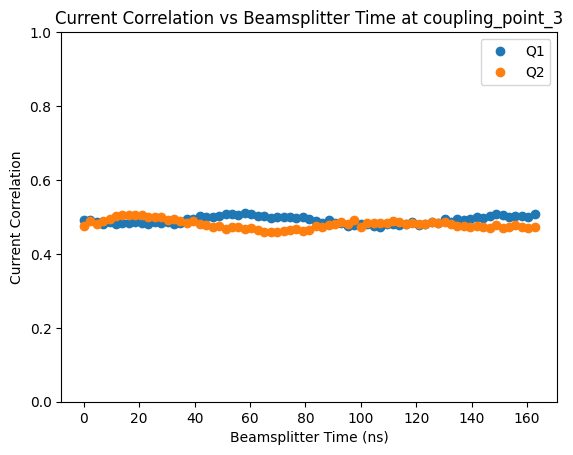

(3, 4)


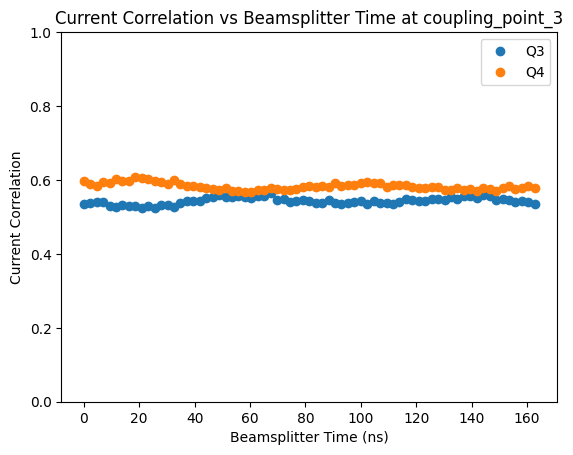

(5, 6)


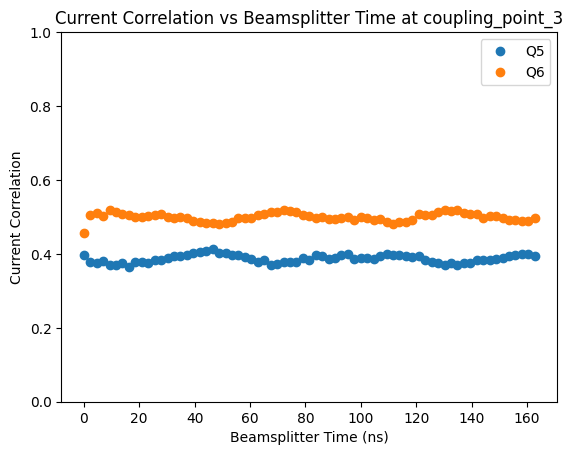

(7, 8)


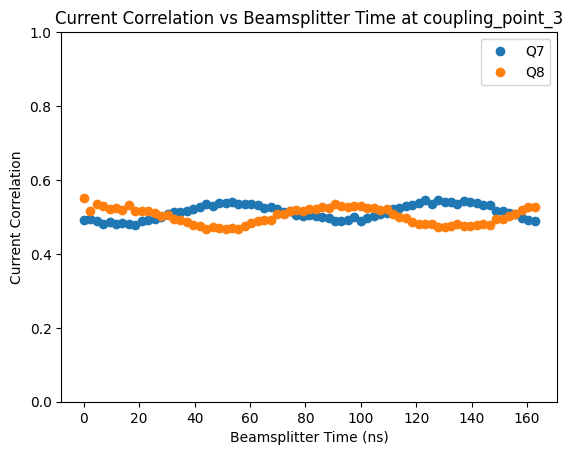

(2, 3)


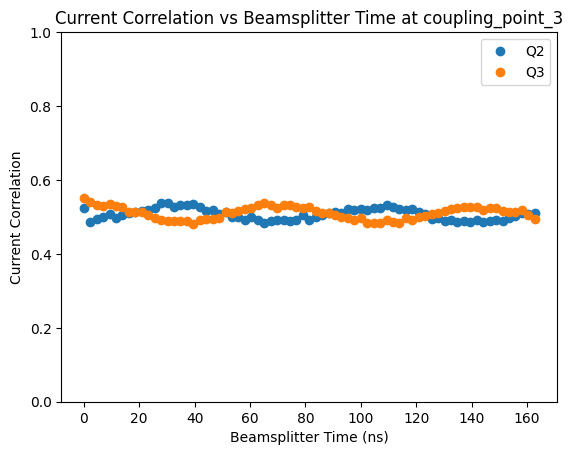

(4, 5)


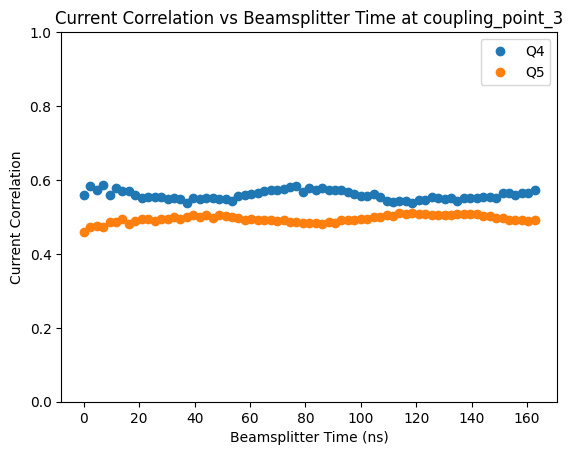

(6, 7)


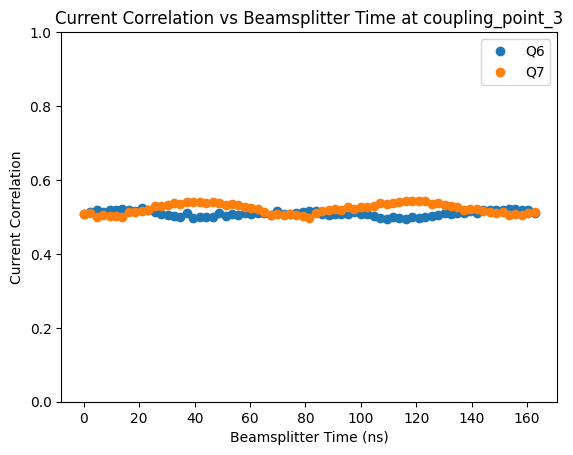

In [127]:
for pair in pair_to_populations:
    print(pair)
    plt.plot(pair_to_times[pair], pair_to_populations[pair][0,:], linestyle='', marker='o', label=f'Q{pair[0]}')
    plt.plot(pair_to_times[pair], pair_to_populations[pair][1,:], linestyle='', marker='o', label=f'Q{pair[1]}')
    plt.xlabel('Beamsplitter Time (ns)')
    plt.ylabel('Current Correlation')
    plt.title(f'Current Correlation vs Beamsplitter Time at {coupling_point}')

    plt.ylim(0, 1)

    plt.legend()
    plt.show()

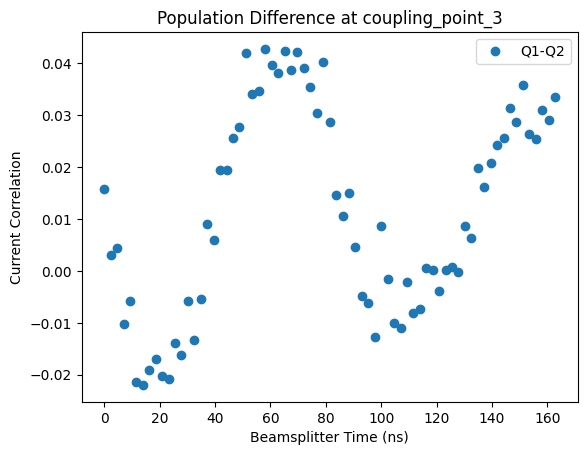

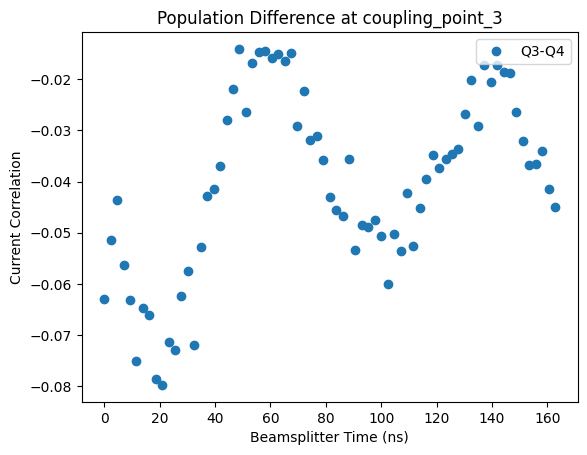

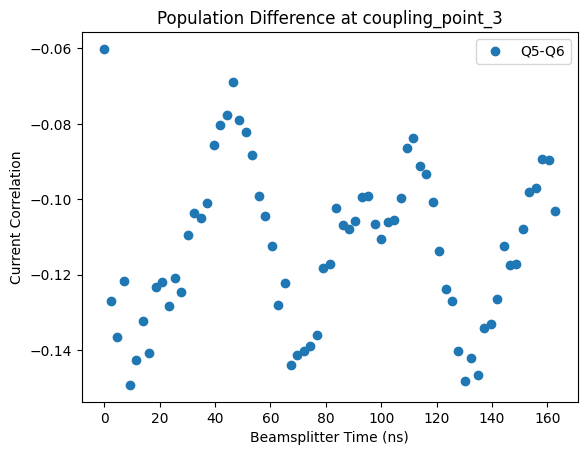

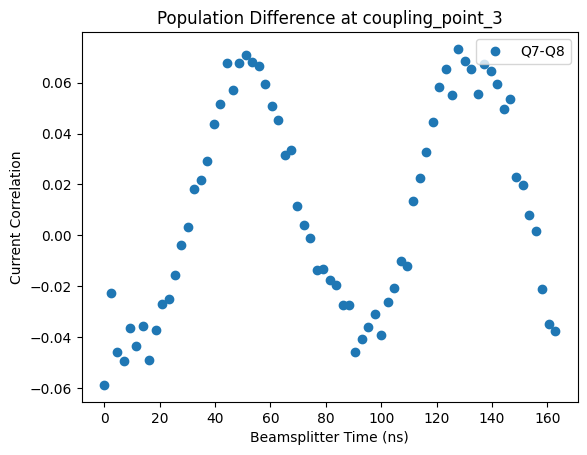

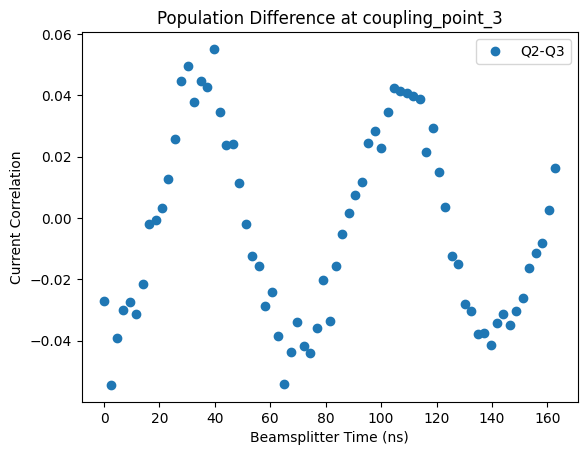

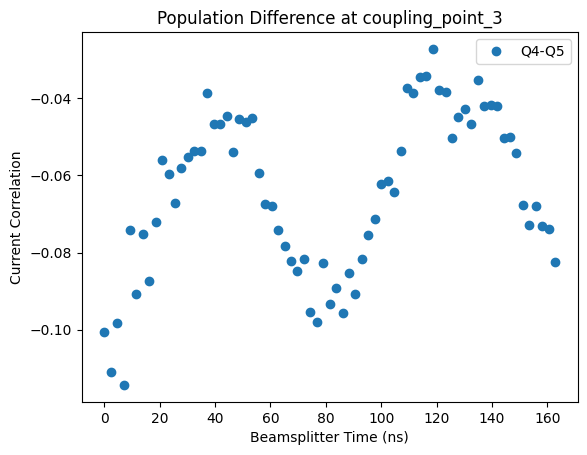

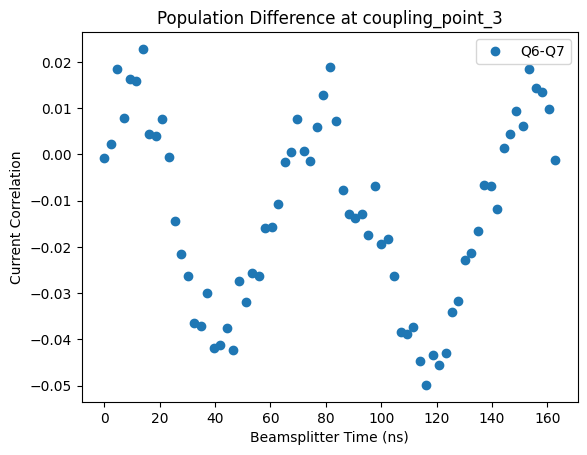

In [128]:
for pair in pair_to_population_difference:
    plt.plot(pair_to_times[pair], pair_to_population_difference[pair], linestyle='', marker='o', label=f'Q{pair[0]}-Q{pair[1]}')
    plt.xlabel('Beamsplitter Time (ns)')
    plt.ylabel('Current Correlation')
    plt.title(f'Population Difference at {coupling_point}')


    plt.legend()
    plt.show()

# 2. Fit Data

In [129]:
# def sin_fit(t, A, omega, phi, offset):
#     return A * np.sin(omega * t + phi) + offset

def sin_fit(t, A, omega, phi, offset, T2):
    return A * np.sin(omega * t + phi) * np.exp(-t / T2) + offset

In [130]:
initial_guess_dict = {}
start_index_dict = {}


if coupling_point == 'coupling_point_1':
    initial_guess_dict = {
        (4,5): [0.06105249016095446, 90, 0, 0.04033543753976913, 100],
        (6,7): [-0.1063313899350671, 73.26194068171398, 1, 0.02338829528646789, 100]
    }
elif coupling_point == 'coupling_point_2_retake':
    initial_guess_dict = {
        (1,2): [-0.1038505363917045, 70, 0, 0.04279365963101924, 100],
        (2,3): [0.15684626869935528, 77.28317927830892, 1, -0.005781540131615496, 100],
        (4,5): [0.059721073833048255, 74.76990515543707, 0.5, -0.07213144591291279, 100],
        (6,7): [-0.10517327497385492, 78.66548004588842, 0, 0.02256082698792016, 1]
    }
    
elif coupling_point == 'coupling_point_3':
    initial_guess_dict = {
        (2,3): [-0.08917944924316193, 80, 0.5, -0.021651318739345244, 100],
        (4,5): [-0.0723138329103176, 80, 0.5, 0.028822953486806472, 100],
        (5,6): [-0.06091163346661568, 120, 0, 0.007455102075835023, 100],
        (6,7): [-0.06091163346661568, 90, 0, -0.007455102075835023, 100],
        (7,8): [0.11226724767927637, 70, 0, -0.012746306708874451, 100]
    }
elif coupling_point == 'coupling_point_4':
    initial_guess_dict = {
        (3,4): [0.5536184918931909, 80.17344451961152, 1.5, -0.006823143262717725, 100],
        (4,5): [0.5710672583375085, 82.43539123019616, 1.5, -0.053074598236795105, 100],
        (5,6): [0.540258716624635, 79.92211710732434, 1.5, -0.05062713439075668, 100],
        (7,8): [0.540258716624635, 79.92211710732434, 1.5, -0.05062713439075668, 100]
    }

    

In [131]:
# amp

if coupling_point.split('_')[2] in ['1','2','3']:
    amp_parities = np.array([-1, 1, -1, 1, -1, 1, -1])
else:
    amp_parities = np.array([-1, -1, -1, -1, -1, -1, -1])

beamsplitter_time: 0.02 us for pair (1, 2)
A, omega, phi, offset
initial_guess: [-0.032346049195102394, 65.84778201924206, 0, 0.011513795809322254, 100]
popt: [-4.17169029e-02  6.80629273e+01  3.40955993e-01  1.35105734e-02
  1.75103930e-01]
pcov: [[ 1.11531442e-05  6.36334112e-04 -6.63388324e-05 -3.58553833e-08
   8.24583121e-05]
 [ 6.36334112e-04  9.30556062e-01 -6.85932093e-02  5.99138587e-05
   3.57726430e-03]
 [-6.63388324e-05 -6.85932093e-02  6.36564853e-03 -1.11113031e-05
  -3.92220937e-04]
 [-3.58553833e-08  5.99138587e-05 -1.11113031e-05  4.51587874e-07
  -1.47383515e-06]
 [ 8.24583121e-05  3.57726430e-03 -3.92220937e-04 -1.47383515e-06
   7.65528490e-04]]
perr: [3.33963234e-03 9.64653338e-01 7.97850145e-02 6.72002882e-04
 2.76681855e-02]


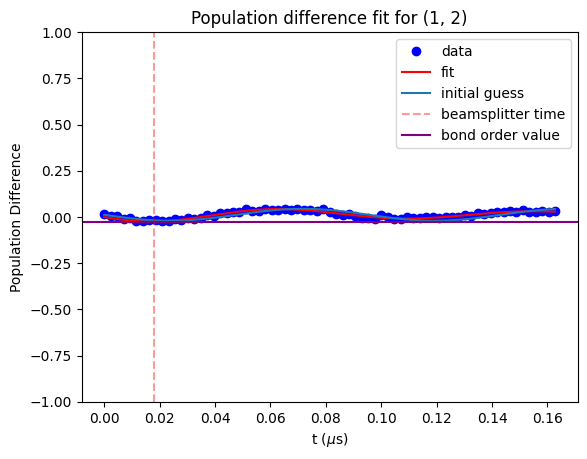

beamsplitter_time: 0.03 us for pair (2, 3)
A, omega, phi, offset
initial_guess: [-0.08917944924316193, 80, 0.5, -0.021651318739345244, 100]
popt: [-4.90143493e-02  8.82386631e+01  1.65443956e+00 -9.36251647e-04
  6.18173295e-01]
pcov: [[ 9.70335856e-06 -2.60933392e-04  3.23376563e-05  9.38748085e-07
   7.52627927e-04]
 [-2.60933392e-04  4.21164246e-01 -3.89632019e-02 -1.00051768e-04
  -1.67777330e-02]
 [ 3.23376563e-05 -3.89632019e-02  4.28768728e-03  1.04277993e-05
   2.28724795e-03]
 [ 9.38748085e-07 -1.00051768e-04  1.04277993e-05  7.11483140e-07
   8.36971547e-05]
 [ 7.52627927e-04 -1.67777330e-02  2.28724795e-03  8.36971547e-05
   6.97715446e-02]]
perr: [0.00311502 0.64897168 0.06548043 0.00084349 0.26414304]


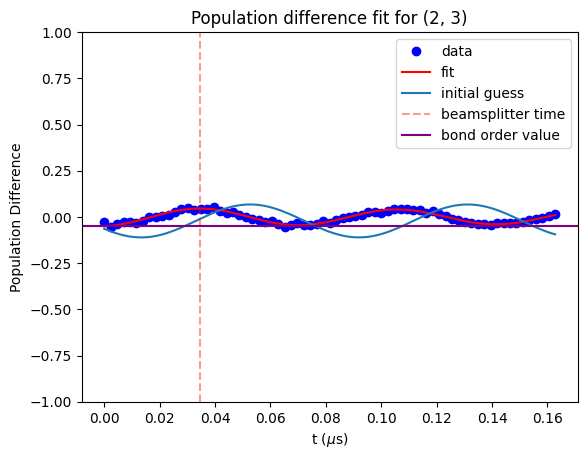

beamsplitter_time: 0.02 us for pair (3, 4)
A, omega, phi, offset
initial_guess: [-0.03280040186018246, 56.67433147075987, 0, -0.040290912779242474, 100]
popt: [-4.08255021e-02  7.82450423e+01  2.02270233e-24 -3.74344026e-02
  1.18204350e-01]
pcov: [[ 1.78218681e-05  1.45073616e-03 -1.28412199e-04 -1.80518179e-07
   7.09835866e-05]
 [ 1.45073616e-03  1.84604308e+00 -1.30487687e-01  2.80229268e-04
   5.21137366e-03]
 [-1.28412199e-04 -1.30487687e-01  1.13677183e-02 -2.57648626e-05
  -4.36252094e-04]
 [-1.80518179e-07  2.80229268e-04 -2.57648626e-05  5.35467452e-07
  -1.93549707e-06]
 [ 7.09835866e-05  5.21137366e-03 -4.36252094e-04 -1.93549707e-06
   3.57798443e-04]]
perr: [4.22159544e-03 1.35869168e+00 1.06619503e-01 7.31756416e-04
 1.89155609e-02]


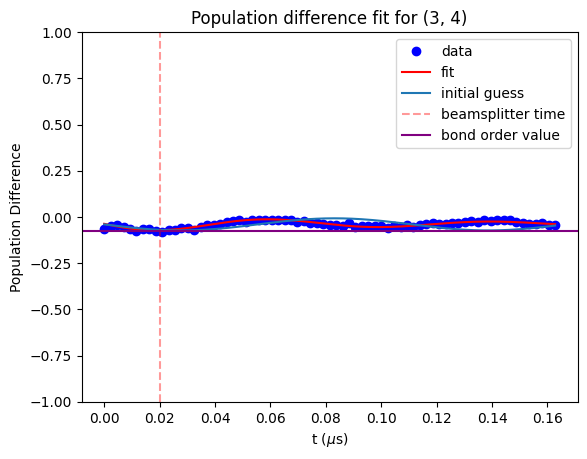

beamsplitter_time: 0.04 us for pair (4, 5)
A, omega, phi, offset
initial_guess: [-0.0723138329103176, 80, 0.5, 0.028822953486806472, 100]
popt: [-2.41142723e-02  7.02151359e+01  2.11393916e+00 -6.39153709e-02
  1.00000000e+03]
pcov: [[ 1.44168619e-05 -1.01355982e-03  1.13239734e-04  8.28621083e-07
   5.60454347e+03]
 [-1.01355982e-03  2.64530192e+00 -2.58678123e-01  2.10028665e-04
  -5.03504653e+05]
 [ 1.13239734e-04 -2.58678123e-01  2.95980426e-02 -4.73027036e-06
   5.13716423e+04]
 [ 8.28621083e-07  2.10028665e-04 -4.73027036e-06  1.33606622e-06
   2.11884180e+02]
 [ 5.60454347e+03 -5.03504653e+05  5.13716423e+04  2.11884180e+02
   2.63527946e+12]]
perr: [3.79695429e-03 1.62643841e+00 1.72040817e-01 1.15588331e-03
 1.62335439e+06]


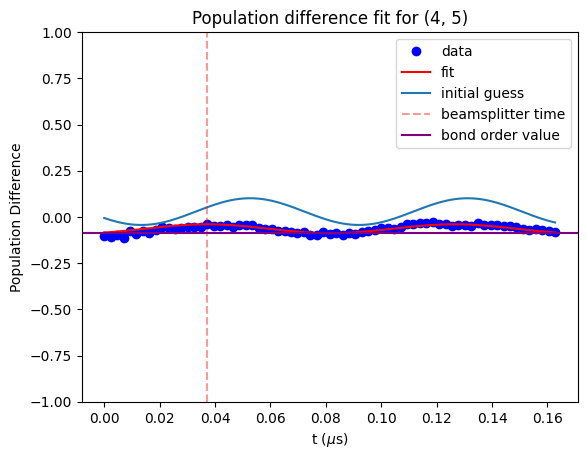

beamsplitter_time: 0.01 us for pair (5, 6)
A, omega, phi, offset
initial_guess: [-0.06091163346661568, 120, 0, 0.007455102075835023, 100]
popt: [-3.26951054e-02  1.05632599e+02  1.87376304e-26 -1.11661573e-01
  3.24180464e-01]
pcov: [[ 3.16157312e-05 -3.11439615e-04  1.39526505e-06  8.52947713e-07
   9.79107727e-04]
 [-3.11439615e-04  2.67924174e+00 -2.12861700e-01 -3.50773899e-05
  -1.90684890e-02]
 [ 1.39526505e-06 -2.12861700e-01  2.15154175e-02 -1.07523825e-05
   6.18895250e-04]
 [ 8.52947713e-07 -3.50773899e-05 -1.07523825e-05  1.51919944e-06
   2.35754504e-05]
 [ 9.79107727e-04 -1.90684890e-02  6.18895250e-04  2.35754504e-05
   3.64613097e-02]]
perr: [5.62278678e-03 1.63683895e+00 1.46681347e-01 1.23255809e-03
 1.90948448e-01]


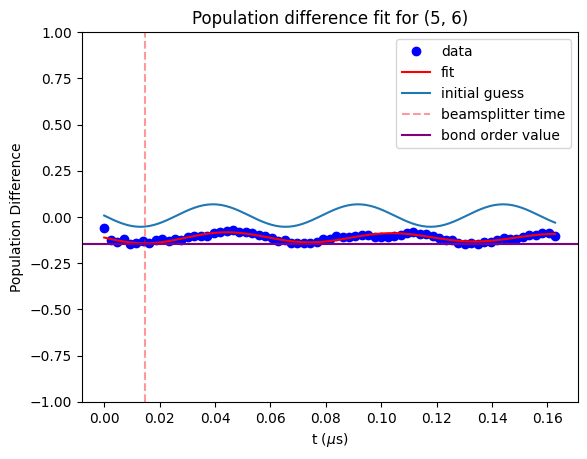

beamsplitter_time: 0.01 us for pair (6, 7)
A, omega, phi, offset
initial_guess: [-0.06091163346661568, 90, 0, -0.007455102075835023, 100]
popt: [ 2.50111246e-02  8.47052522e+01  1.14701978e+00 -1.56976187e-02
  1.00000000e+03]
pcov: [[ 8.98321395e-06  1.23561064e-04 -2.83669805e-05  9.07692249e-07
  -3.19528497e+03]
 [ 1.23561064e-04  1.32488961e+00 -1.17638485e-01 -1.55879680e-04
  -5.81356788e+03]
 [-2.83669805e-05 -1.17638485e-01  1.25269051e-02  9.84190845e-06
   6.99401461e+03]
 [ 9.07692249e-07 -1.55879680e-04  9.84190845e-06  7.43525129e-07
  -3.69078424e+02]
 [-3.19528497e+03 -5.81356788e+03  6.99401461e+03 -3.69078424e+02
   1.31369956e+12]]
perr: [2.99720102e-03 1.15103849e+00 1.11923658e-01 8.62279032e-04
 1.14616734e+06]


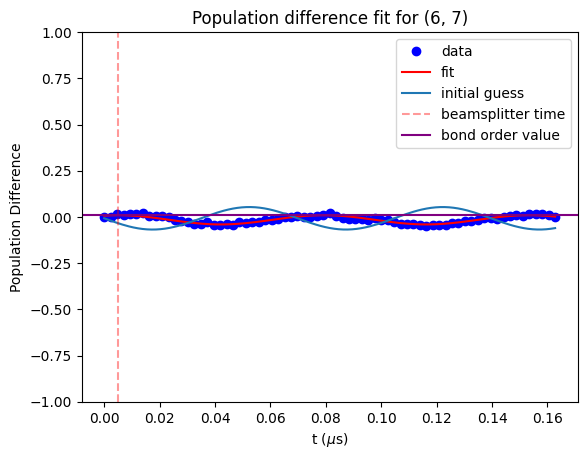

beamsplitter_time: 0.03 us for pair (7, 8)
A, omega, phi, offset
initial_guess: [0.11226724767927637, 70, 0, -0.012746306708874451, 100]
popt: [2.93775479e-02 5.70234520e+01 4.03922706e-25 1.47060844e-02
 1.00000000e+03]
pcov: [[ 2.03944187e-04 -2.50818337e-02  2.49737779e-03  9.06824797e-06
  -6.54702310e+04]
 [-2.50818337e-02  3.42521847e+01 -3.32525506e+00 -8.68470125e-03
   1.07276739e+07]
 [ 2.49737779e-03 -3.32525506e+00  3.66626600e-01  9.64362194e-04
  -1.02728122e+06]
 [ 9.06824797e-06 -8.68470125e-03  9.64362194e-04  2.13777816e-05
  -5.82837228e+03]
 [-6.54702310e+04  1.07276739e+07 -1.02728122e+06 -5.82837228e+03
   2.54645830e+13]]
perr: [1.42809029e-02 5.85253660e+00 6.05496986e-01 4.62361131e-03
 5.04624444e+06]


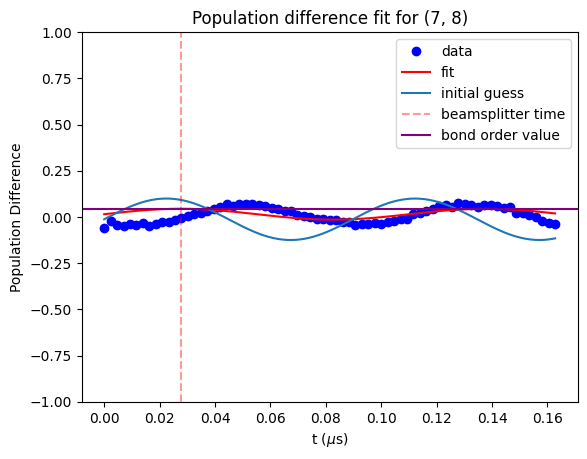

In [132]:
couplings = coupling_point_config['coupling']

all_pairs = [(i,i+1) for i in range(1,8)]

fit_pairs = [(1,2)]
fit_pairs = [(1,2), (3,4), (5,6), (7,8)]

fit_pairs = all_pairs

# fit_pairs = [(5,6)]

start_cutoff = 10

pair_to_popt = {}
pair_to_perr = {}

pair_to_beamsplitter_time = {}

pair_to_bond_order_parameter = {}
pair_to_bond_order_parameter_corrected = {}

pair_to_bond_order_error = {}
pair_to_bond_order_error_corrected = {}

plot_initial_guess = True


for pair in fit_pairs:

    index = all_pairs.index(pair)
    times = pair_to_times[pair]
    times_mus = times*1e-3
    population_difference = pair_to_population_difference[pair]

    coupling_MHz = abs(couplings[f'J_{pair[0]}{pair[1]}'])

    offset_guess = np.mean(population_difference)
    amplitude_guess = np.abs((np.max(population_difference) - np.min(population_difference)) / 2)
    frequency_guess = 2 * coupling_MHz * 2 * np.pi

    if pair in initial_guess_dict:
        initial_guess = initial_guess_dict[pair]
    else:
        initial_guess = [amplitude_guess, frequency_guess, 0, offset_guess, 100]

        # compare mean squared error for original vs phase-shifted (pi) initial guesses
        pred_orig = sin_fit(times_mus, *initial_guess)
        mse_orig = np.mean((population_difference - pred_orig)**2)

        initial_guess_neg = initial_guess.copy()
        initial_guess_neg[0] *= -1
        pred_pi = sin_fit(times_mus, *initial_guess_neg)
        mse_pi = np.mean((population_difference - pred_pi)**2)

        if mse_pi < mse_orig:
            initial_guess = initial_guess_neg


    bounds = ((-2*amplitude_guess, 0, 0, -1,0.1), (2*amplitude_guess, 4*frequency_guess, np.pi, 1,1000))

    # fit

    popt, pcov = curve_fit(sin_fit, times_mus[start_cutoff:], population_difference[start_cutoff:], p0=initial_guess, bounds=bounds)
    
    amp, frequency, phase, offset, T2 = popt
    perr = np.sqrt(np.diag(pcov))

    beamsplitter_time = (np.pi/2 - phase)/frequency
    while beamsplitter_time < 0:
        beamsplitter_time += 2*np.pi/frequency
    while beamsplitter_time > np.pi/frequency:
        beamsplitter_time -= np.pi/frequency


    pair_to_popt[pair] = popt
    pair_to_perr[pair] = perr

    pair_to_beamsplitter_time[pair] = beamsplitter_time

    pair_to_bond_order_parameter[pair] = np.abs(amp)*amp_parities[index] + offset
    pair_to_bond_order_parameter_corrected[pair] = np.abs(amp)*amp_parities[index]

    bond_order_error = np.sqrt(perr[0]**2 + perr[3]**2 + 2*pcov[0,3])
    pair_to_bond_order_error[pair] = bond_order_error

    bond_order_error_corrected = perr[0]
    pair_to_bond_order_error_corrected[pair] = bond_order_error_corrected



    print(f'beamsplitter_time: {beamsplitter_time:.2f} us for pair {pair}')

    fit_times = np.linspace(times_mus[0], times_mus[-1], 201)

    plt.plot(times_mus, population_difference, linestyle='', color='blue', marker='o', label='data')

    plt.plot(fit_times, sin_fit(fit_times, *popt), color='red', label='fit')

    if plot_initial_guess:
        print(f'A, omega, phi, offset')
        print(f'initial_guess: {initial_guess}')
        print(f'popt: {popt}')
        print(f'pcov: {pcov}')
        print(f'perr: {perr}')
        plt.plot(fit_times, sin_fit(fit_times, *initial_guess), label='initial guess')

    plt.axvline(x=beamsplitter_time, color='red', linestyle='--', label='beamsplitter time', alpha=0.4)

    plt.axhline(y=amp + offset, color='purple', label='bond order value')

    plt.xlabel('t ($\mu$s)')
    plt.ylabel('Population Difference')


    plt.title(f'Population difference fit for {pair}')

    plt.ylim(-1,1)

    plt.legend()
    plt.show()

    

In [133]:
print(pair_to_bond_order_parameter[(1,2)])

-0.02820632954536313


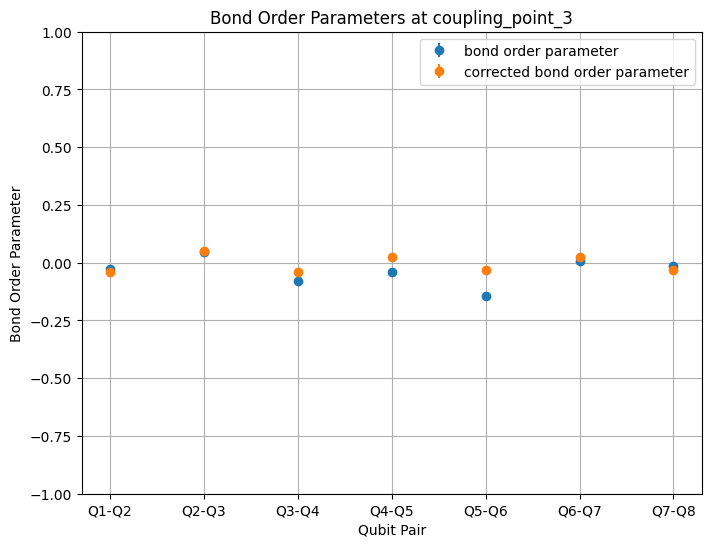

In [134]:
### plot all bond order parameters
plt.figure(figsize=(8,6))

bond_order_parameters = []
bond_order_parameters_errors = []

bond_order_parameters_corrected = []
bond_order_parameters_errors_corrected = []

pairs = []

for pair in pair_to_bond_order_parameter:


    pairs.append(pair)

    bond_order_parameters.append(pair_to_bond_order_parameter[pair])
    bond_order_parameters_errors.append(pair_to_bond_order_error[pair])

    bond_order_parameters_corrected.append(pair_to_bond_order_parameter_corrected[pair])
    bond_order_parameters_errors_corrected.append(pair_to_bond_order_error_corrected[pair])

bond_order_parameters = np.array(bond_order_parameters)
bond_order_parameters_errors = np.array(bond_order_parameters_errors)
bond_order_parameters_corrected = np.array(bond_order_parameters_corrected)
bond_order_parameters_errors_corrected = np.array(bond_order_parameters_errors_corrected)


plt.errorbar(range(len(pairs)), bond_order_parameters, yerr=bond_order_parameters_errors, fmt='o', label='bond order parameter')
plt.errorbar(range(len(pairs)), bond_order_parameters_corrected, yerr=bond_order_parameters_errors_corrected, fmt='o', label='corrected bond order parameter')

plt.xticks(range(len(pairs)), [f'Q{pair[0]}-Q{pair[1]}' for pair in pairs])
plt.xlabel('Qubit Pair')

plt.ylabel('Bond Order Parameter')
plt.title(f'Bond Order Parameters at {coupling_point}')

plt.ylim(-1, 1)

plt.legend()
plt.grid()
plt.show()  

In [135]:
# calculate total bond order parameter

bond_order_total = 0
bond_order_total_error = np.sqrt(np.sum(np.power(bond_order_parameters_errors, 2)))


bond_order_total_corrected = 0
bond_order_total_error_corrected = np.sqrt(np.sum(np.power(bond_order_parameters_errors_corrected, 2)))

for i in range(len(bond_order_parameters)):
    bond_order_total += bond_order_parameters[i] * (-1)**(i+1)

for i in range(len(bond_order_parameters_corrected)):
    bond_order_total_corrected += bond_order_parameters_corrected[i] * (-1)**(i+1)

print(f'Total Bond Order Parameter: {bond_order_total:.4f} ± {bond_order_total_error:.4f}')
print(f'Total Corrected Bond Order Parameter: {bond_order_total_corrected:.4f} ± {bond_order_total_error_corrected:.4f}')

Total Bond Order Parameter: 0.2831 ± 0.0187
Total Corrected Bond Order Parameter: 0.2428 ± 0.0173


In [136]:
np.power(bond_order_parameters_errors, 2)

array([1.15330213e-05, 1.22923379e-05, 1.79962992e-05, 1.74101703e-05,
       3.48408260e-05, 1.15421236e-05, 2.43458464e-04])

# 3. Save data

In [137]:
data_dictionary = {}

for pair in pair_to_bond_order_parameter:
    data_dictionary[pair] = {}

    data_dictionary[pair]['times'] = pair_to_times[pair]

    data_dictionary[pair]['beamsplitter_time'] = pair_to_beamsplitter_time[pair]

    data_dictionary[pair]['population_difference'] = pair_to_population_difference[pair]
    
    data_dictionary[pair]['bond_order_value'] = pair_to_bond_order_parameter[pair]
    data_dictionary[pair]['bond_order_error'] = pair_to_bond_order_error[pair]

    data_dictionary[pair]['bond_order_value_corrected'] = pair_to_bond_order_parameter_corrected[pair]
    data_dictionary[pair]['bond_order_error_corrected'] = pair_to_bond_order_error_corrected[pair]

data_dictionary['bond_order_total'] = bond_order_total
data_dictionary['bond_order_total_error'] = bond_order_total_error

data_dictionary['bond_order_total_corrected'] = bond_order_total_corrected
data_dictionary['bond_order_total_error_corrected'] = bond_order_total_error_corrected

In [138]:
def backup_data(data_filename):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_only = os.path.basename(data_filename)
    name, ext = os.path.splitext(filename_only)
    backup_name = f"{name}_{timestamp}{ext}"
    backup_path = os.path.join('data_backups', backup_name)
    shutil.copy2(data_filename, backup_path)

def save_nested_dict_to_hdf5(filename, data, save_backup=True):

    if save_backup:
        backup_data(filename)

    with h5py.File(filename, 'w') as f:
        def _save_dict(group, dictionary):
            for key, value in dictionary.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(str(key))
                    _save_dict(subgroup, value)
                elif isinstance(value, np.ndarray):
                    group.create_dataset(key, data=value, compression='gzip')
                elif isinstance(value, list):
                    group.create_dataset(key, data=np.array(value), compression='gzip')
                else:
                    group.attrs[key] = value  # Store scalars as attributes
        
        _save_dict(f, data)

def update_data_file(filename, data, keys, save_backup=True):
    if save_backup:
        backup_data(filename)
    
    with h5py.File(filename, 'a') as f:  # Open in append mode
        def _navigate_to_parent(group, key_path):
            """Navigate to the parent group of the target location"""
            current_group = group
            for key in key_path[:-1]:  # All keys except the last one
                if str(key) in current_group:
                    current_group = current_group[str(key)]
                else:
                    # Create the group if it doesn't exist
                    current_group = current_group.create_group(str(key))
            return current_group
        
        def _save_data_at_location(group, key, value):
            """Save data at a specific location, replacing if it exists"""
            # Remove existing data if it exists
            if key in group:
                del group[key]
            
            # Save new data
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                _save_dict(subgroup, value)
            elif isinstance(value, np.ndarray):
                group.create_dataset(key, data=value, compression='gzip')
            elif isinstance(value, list):
                group.create_dataset(key, data=np.array(value), compression='gzip')
            else:
                group.attrs[key] = value  # Store scalars as attributes
        
        def _save_dict(group, dictionary):
            """Helper function to save nested dictionaries"""
            for key, value in dictionary.items():
                _save_data_at_location(group, str(key), value)
        
        # Navigate to the parent location
        parent_group = _navigate_to_parent(f, keys)
        
        # Save the data at the final key location
        final_key = str(keys[-1])
        _save_data_at_location(parent_group, final_key, data)

In [139]:
# # this overwrits the whole file !!! be careful

# data_filename = 'bond_order_data.h5'
# save_nested_dict_to_hdf5(data_filename, {'data': {coupling_point: {eigenstate: data_dictionary}}})

In [140]:
data_filename = 'bond_order_data.h5'

keys = ('data', coupling_point, eigenstate)

update_data_file(data_filename, data_dictionary, keys=keys, save_backup=True)
